In [136]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import yfinance as yf
import scipy.stats as stats

In [137]:
df = pd.read_excel("../financial_data/vinfast_stock_data.xlsx")

In [138]:
df

,Date,Open,High,Low,CloseClosing price adjusted for splits.,Adj CloseAdjusted closing price adjusted for splits and dividend and/or capital gain distributions.,Volume
0,2026-04-28 00:00:00,4.16,4.195,4.000,4.060,4.060,834600
1,2026-04-27 00:00:00,4.23,4.340,4.157,4.210,4.210,650700
2,2026-04-24 00:00:00,4.41,4.450,4.335,4.360,4.360,457200
3,2026-04-23 00:00:00,4.57,4.605,4.140,4.410,4.410,1333100
4,2026-04-22 00:00:00,4.88,5.120,4.580,4.690,4.690,1409000
...,...,...,...,...,...,...,...
1160,13 Sept 2021,9.71,9.710,9.710,9.710,9.710,400
1161,10 Sept 2021,9.69,9.690,9.680,9.680,9.680,700
1162,9 Sept 2021,9.61,9.691,9.610,9.682,9.682,400
1163,8 Sept 2021,9.71,9.710,9.710,9.710,9.710,3700


In [139]:
df.columns = ['date', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume']

df['date'] = pd.to_datetime(df['date'], format='mixed')

In [140]:
df

,date,open,high,low,close,adjusted_close,volume
0,2026-04-28,4.16,4.195,4.000,4.060,4.060,834600
1,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700
2,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
3,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
4,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
...,...,...,...,...,...,...,...
1160,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
1161,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1162,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1163,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700


In [141]:
df.isna().sum()

date              0
open              0
high              0
low               0
close             0
adjusted_close    0
volume            0
dtype: int64

In [142]:
df.duplicated().sum()

0

In [143]:
df['date'] = pd.to_datetime(df['date'], format="mixed")


In [144]:
df = df.sort_values(['date'],ascending=True) 
df


,date,open,high,low,close,adjusted_close,volume
1164,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1163,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
1162,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1161,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1160,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
4,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
3,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
2,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
1,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700


In [145]:
df.corr(numeric_only=True)

,open,high,low,close,adjusted_close
open,1.000000,0.977757,0.981945,0.966715,0.966715
high,0.977757,1.000000,0.964280,0.985586,0.985586
low,0.981945,0.964280,1.000000,0.982141,0.982141
close,0.966715,0.985586,0.982141,1.000000,1.000000
adjusted_close,0.966715,0.985586,0.982141,1.000000,1.000000


In [146]:
plt.style.use("bmh")

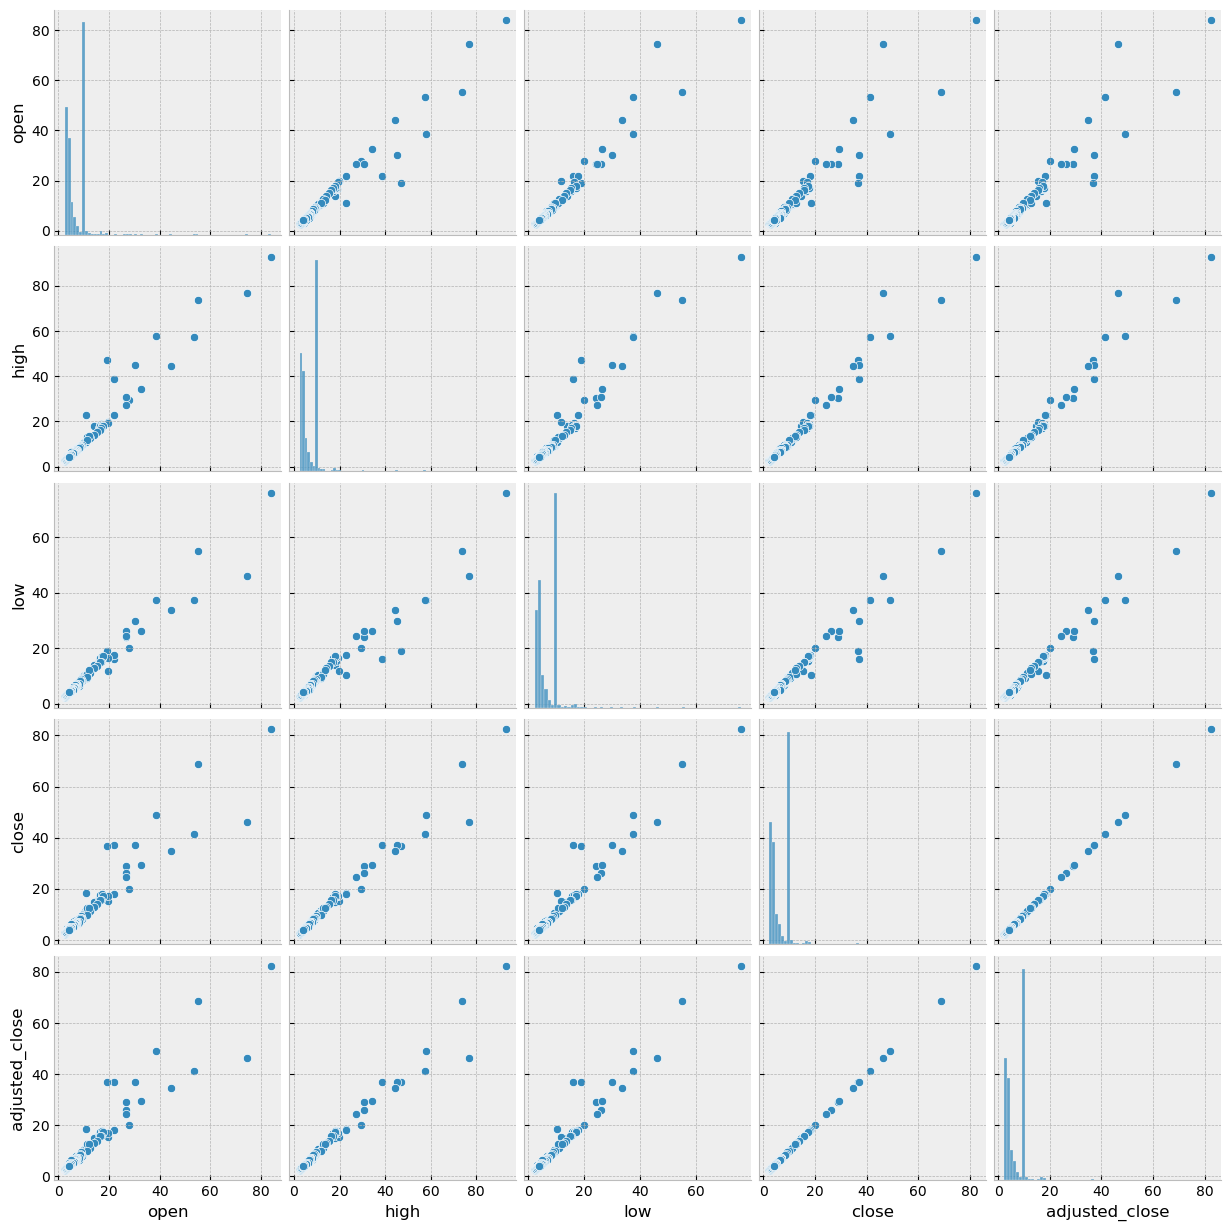

In [147]:
sns.pairplot(df)

In [148]:
df.index = df.date 
df.drop(['date'],axis=1,inplace=True) 


In [149]:
df

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...
2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
2026-04-24,4.41,4.450,4.335,4.360,4.360,457200


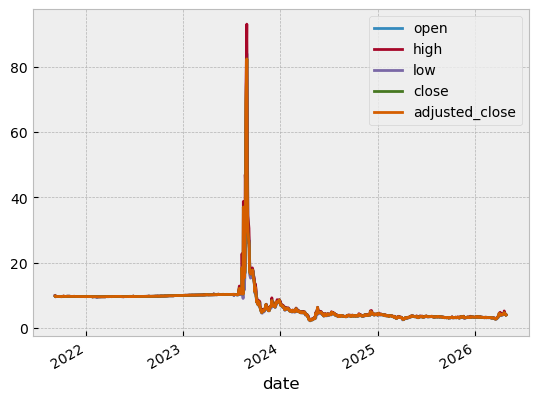

In [150]:
plt.Figure(figsize=(10,10))
df.plot(kind='line')

plt.show()

In [151]:
df.head()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400


In [152]:
df.reset_index(inplace=True)

In [153]:
df

,date,open,high,low,close,adjusted_close,volume
0,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
3,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
4,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
1160,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
1161,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
1162,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
1163,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700


In [154]:
df = df.sort_values(['date'],ascending=True)

df = df[df.date > '2024-01-01']

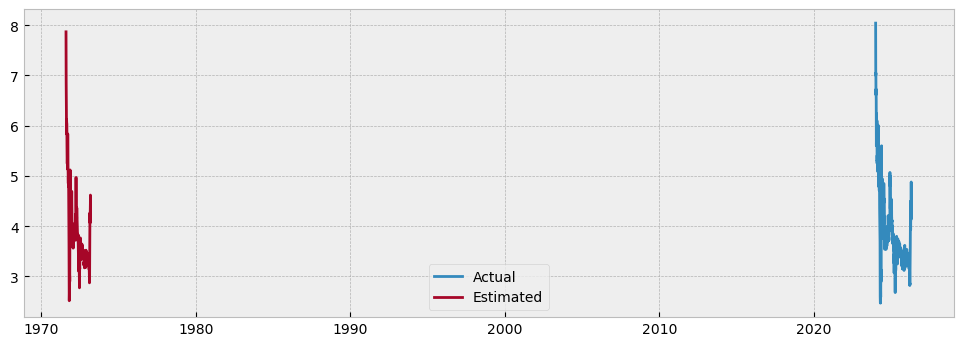

In [155]:
from statsmodels.tsa.seasonal import STL
open_price = pd.DataFrame(df[['open', 'date']])


stl = STL(open_price['open'], period=3) 
result = stl.fit()
seasonal, trend, resid = result.seasonal, result.trend, result.resid 


estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price.date, open_price.open) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

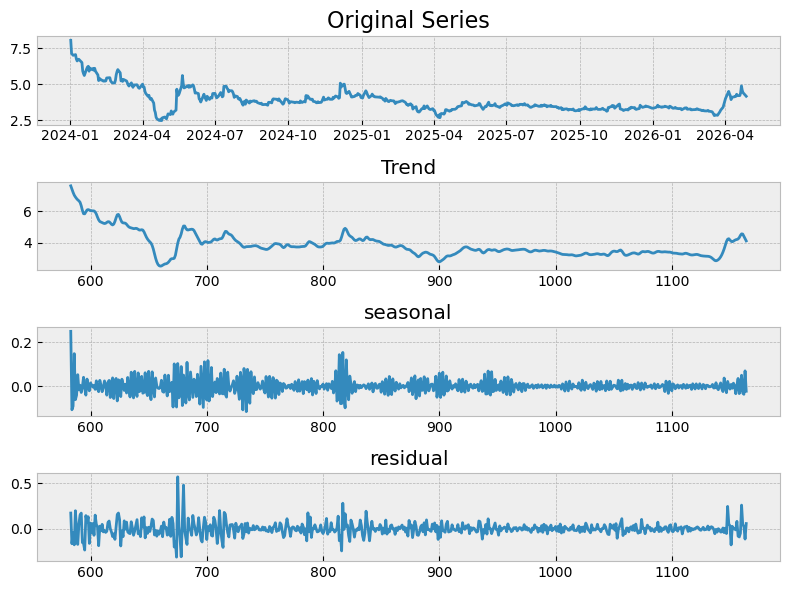

In [156]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid 

plt.figure(figsize=(8,6)) 
plt.subplot(4,1,1) 
plt.plot(df.date, df['open']) 
plt.title("Original Series", fontsize=16) 

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend") 

plt.subplot(4,1,3) 
plt.plot(seasonal) 
plt.title("seasonal") 

plt.subplot(4,1,4) 
plt.plot(resid) 
plt.title("residual")
plt.tight_layout()

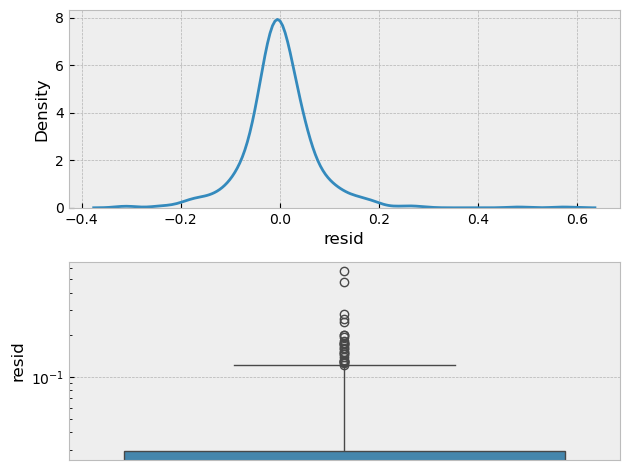

Shapiro -> ShapiroResult(statistic=0.8899385112825087, pvalue=5.828630661555075e-20)


In [157]:
fig, axes=plt.subplots(2) 

sns.kdeplot(resid, ax=axes[0])
sns.boxplot(resid, ax=axes[1])
axes[1].set_yscale("log") 
plt.tight_layout()
plt.show()

import scipy.stats as stats 


print (f"Shapiro -> {stats.shapiro(resid)}")

In [158]:
df

,date,open,high,low,close,adjusted_close,volume
583,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
584,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
585,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
586,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
587,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
1160,2026-04-22,4.880,5.120,4.580,4.69,4.69,1409000
1161,2026-04-23,4.570,4.605,4.140,4.41,4.41,1333100
1162,2026-04-24,4.410,4.450,4.335,4.36,4.36,457200
1163,2026-04-27,4.230,4.340,4.157,4.21,4.21,650700


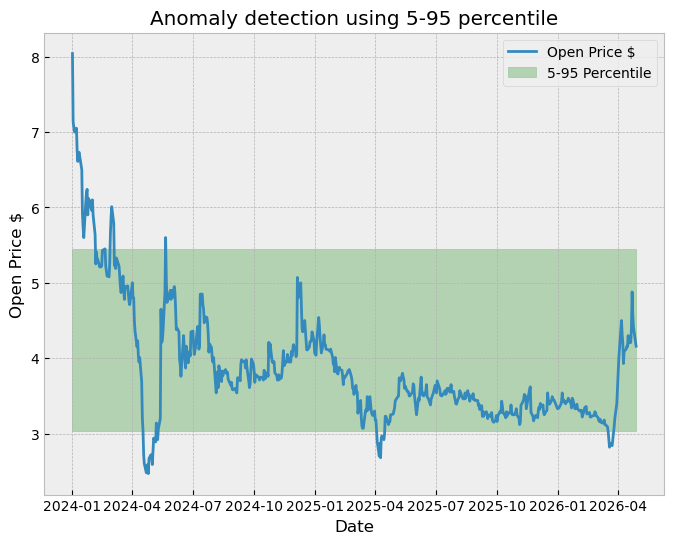

In [159]:
plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = np.percentile(df.open, 95) 
lower = np.percentile(df.open, 5) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 5-95 percentile") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '5-95 Percentile'])
plt.show()

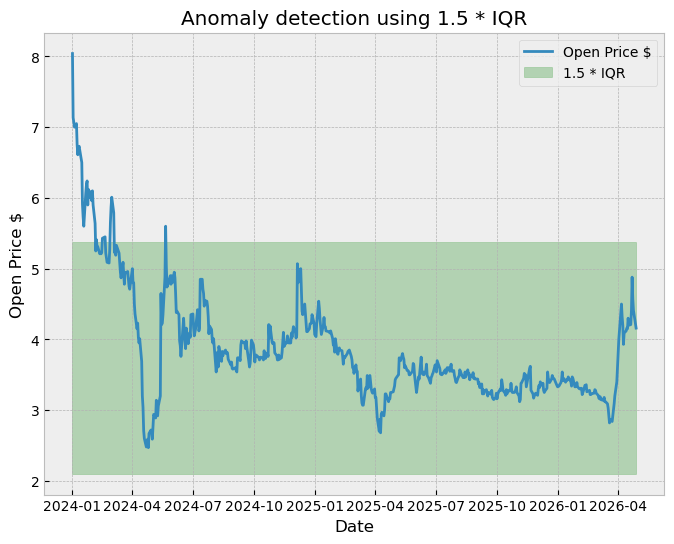

In [160]:
# using IQR

iqr = stats.iqr(df['open']) 




plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = (1.5 * iqr) + np.percentile(df.open, 75)
lower = np.percentile(df.open, 25) - (1.5 * iqr)

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 1.5 * IQR") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '1.5 * IQR'])
plt.show()

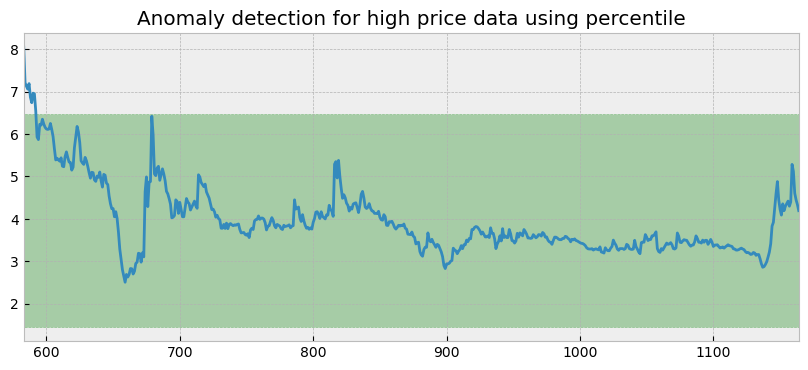

In [161]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['high'].mean() 
open_dev = df['high'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using percentile")
plt.show()

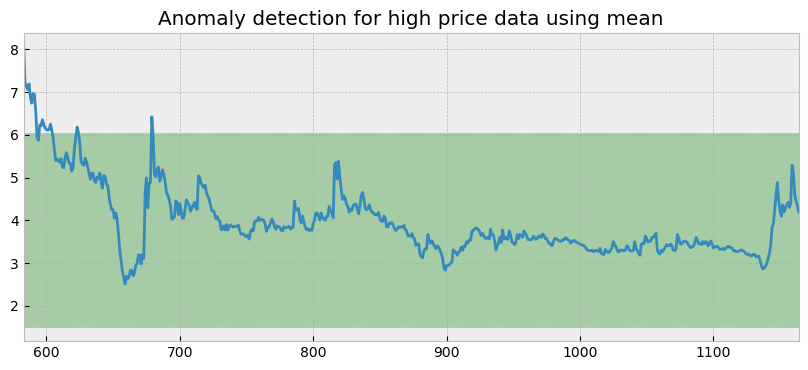

In [162]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['low'].mean() 
open_dev = df['low'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using mean")
plt.show()

In [163]:

df.volume = pd.to_numeric(df.volume)

{'whiskers': [<matplotlib.lines.Line2D at 0x30b80d8b0>,
 'caps': [<matplotlib.lines.Line2D at 0x30b81c710>,
 'boxes': [<matplotlib.lines.Line2D at 0x30b80ef90>],
 'medians': [<matplotlib.lines.Line2D at 0x30b81ee10>],
 'fliers': [<matplotlib.lines.Line2D at 0x30b81c800>],
 'means': []}

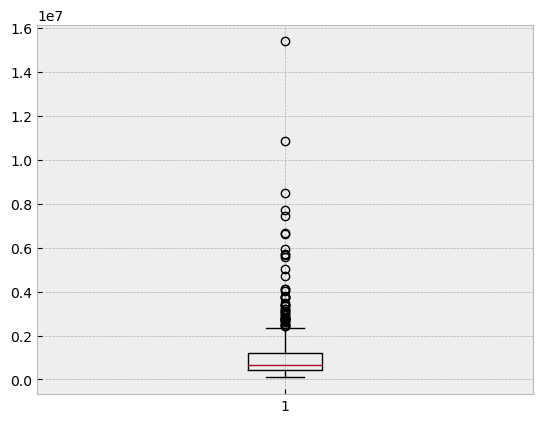

In [164]:
plt.boxplot(df.volume)

In [165]:
min(df.volume)

98200

In [166]:
df.iloc[5]

date              2024-01-09 00:00:00
open                             6.75
high                             6.87
low                              6.41
close                            6.65
adjusted_close                   6.65
volume                        3327700
Name: 588, dtype: object

In [167]:
df.reset_index(inplace=True)

In [168]:
df.head()

,index,date,open,high,low,close,adjusted_close,volume
0,583,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,584,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,585,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,586,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,587,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [169]:
df.drop(['index'],axis=1,inplace=True)

In [170]:

print ("Creating day, month, year...")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date'],ascending=True)

df['day'] = df['date'].dt.day 
df['month'] = df['date'].dt.month 
df['year'] = df['date'].dt.year

df = df.sort_values(['date'],ascending=True) 
print ("Splitting into X_train, X_test, Y_train, Y_test...")
X = df[['high','low', 'adjusted_close', 'day', 'month', 'year']]
train_size=round(df.shape[0]*0.8)
test_size=round(df.shape[0]*0.2)
# replacing the anomalies
X_train = X.head(train_size)
 
X_test = X.tail(test_size)




def impute_median(column): 
    print (f"Computing for column: {column}")
    median = X_train[column].median() 
    print (f"median: {median}")
    std = X_train[column].std() 
    print (f"std: {std}")
    mean = X_train[column].mean() 
    print (f"mean: {mean}")
    # calculating the upper limit

    iqr = stats.iqr(df[column])


    upper = (1.5 * iqr) + np.percentile(X_train[column], 75)
    lower=np.percentile(X_train[column], 25) - (1.5 * iqr)
    print (f"upper: {upper}")
    print (f"lower: {lower}")
    # checking if the value is above or below 
    print ("Imputing...")

    values = [median if value > upper or value < lower else value for value in X_train[column]]
    print ("Done") 
    print ("----------------------")
    return values, median, upper, lower

print ("Imputing...")

# imputing mean for df['open']
iqr = stats.iqr(df['open']) 
upper = (1.5 * iqr) + np.percentile(df['open'], 75)
lower=np.percentile(df['open'], 25) - (1.5 * iqr)
median = df['open'].median()
df['open_imputed'] = [median if value > upper or value < lower else value for value in df['open']]




for column in X_train: 
    # this will impute X_train and X_test simultaneously
    print (f"column: {column}")

    X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)

    
    X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]

    print ("Done...")
    print ("------------------")




# -------------------------- CREATING THE LAGGING
y = df.open.values.reshape(-1,1)



Y_train = y[0:train_size]
Y_test = y[train_size:df.shape[0]]

X_train = X_train.drop(['day_imputed', 'month_imputed', 'year_imputed'],axis=1)
X_test = X_test.drop(['day_imputed', 'month_imputed', 'year_imputed'],axis=1)


Creating day, month, year...
Splitting into X_train, X_test, Y_train, Y_test...
Imputing...
column: high
Computing for column: high
median: 3.83
std: 0.8777066884512452
mean: 4.066912017167382
upper: 5.6602500000000004
lower: 2.1887499999999998
Imputing...
Done
----------------------
Done...
------------------
column: low
Computing for column: low
median: 3.6875
std: 0.7992202161378477
mean: 3.8586030042918456
upper: 5.203500000000001
lower: 2.241249999999999
Imputing...
Done
----------------------
Done...
------------------
column: adjusted_close
Computing for column: adjusted_close
median: 3.75
std: 0.8330754018429259
mean: 3.959388412017167
upper: 5.42375
lower: 2.2337500000000006
Imputing...
Done
----------------------
Done...
------------------
column: day
Computing for column: day
median: 15.5
std: 8.81051209909186
mean: 15.65236051502146
upper: 45.5
lower: -14.5
Imputing...
Done
----------------------
Done...
------------------
column: month
Computing for column: month
median: 6

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/3440666658.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/3440666658.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/34406

In [176]:
X_train

,high,low,adjusted_close,day,month,year,high_imputed,low_imputed,adjusted_close_imputed
0,8.050,7.000,7.05,2,1,2024,3.830,3.6875,3.75
1,7.210,6.835,7.08,3,1,2024,3.830,3.6875,3.75
2,7.130,6.900,7.07,4,1,2024,3.830,3.6875,3.75
3,7.060,6.900,7.02,5,1,2024,3.830,3.6875,3.75
4,7.190,6.750,6.79,8,1,2024,3.830,3.6875,3.75
...,...,...,...,...,...,...,...,...,...
461,3.220,3.130,3.18,3,11,2025,3.220,3.1300,3.18
462,3.180,3.100,3.14,4,11,2025,3.180,3.1000,3.14
463,3.440,3.140,3.40,5,11,2025,3.440,3.1400,3.40
464,3.455,3.295,3.40,6,11,2025,3.455,3.2950,3.40


In [177]:
print (np.shape(Y_train)) 
print (np.shape(Y_test))

(466, 1)
(116, 1)


In [178]:
print (np.shape(X_train)) 
print (np.shape(X_test))

(466, 9)
(116, 9)


In [179]:
X_test

,high,low,adjusted_close,day,month,year,high_imputed,low_imputed,adjusted_close_imputed
466,3.630,3.420,3.530,10,11,2025,3.630,3.420,3.530
467,3.570,3.460,3.485,11,11,2025,3.570,3.460,3.485
468,3.490,3.400,3.470,12,11,2025,3.490,3.400,3.470
469,3.510,3.330,3.360,13,11,2025,3.510,3.330,3.360
470,3.515,3.330,3.460,14,11,2025,3.515,3.330,3.460
...,...,...,...,...,...,...,...,...,...
577,5.120,4.580,4.690,22,4,2026,5.120,4.580,4.690
578,4.605,4.140,4.410,23,4,2026,4.605,4.140,4.410
579,4.450,4.335,4.360,24,4,2026,4.450,4.335,4.360
580,4.340,4.157,4.210,27,4,2026,4.340,4.157,4.210


In [180]:
df.shape

(582, 11)

In [181]:


# lagged adjusted close



lagged_adjusted_close = X_train['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_train['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted high
lagged_high = X_train['high_imputed'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_train['lagged_high'] = lagged_high 

# lagged low 
lagged_low = X_train['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_train['lagged_low'] = lagged_low 

X_train.head()
# ----------------------------



# lagged adjusted close


lagged_adjusted_close = X_test['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_test['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted high
lagged_high = X_test['high_imputed'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_test['lagged_high'] = lagged_high 

# lagged low 
lagged_low = X_test['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_test['lagged_low'] = lagged_low 







In [182]:
X_train.head()

,high,low,adjusted_close,day,month,year,high_imputed,low_imputed,adjusted_close_imputed,lagged_adjusted_close,lagged_high,lagged_low
0,8.05,7.000,7.05,2,1,2024,3.83,3.6875,3.75,0.00,0.00,0.0000
1,7.21,6.835,7.08,3,1,2024,3.83,3.6875,3.75,3.75,3.83,3.6875
2,7.13,6.900,7.07,4,1,2024,3.83,3.6875,3.75,3.75,3.83,3.6875
3,7.06,6.900,7.02,5,1,2024,3.83,3.6875,3.75,3.75,3.83,3.6875
4,7.19,6.750,6.79,8,1,2024,3.83,3.6875,3.75,3.75,3.83,3.6875


In [183]:
X_test

,high,low,adjusted_close,day,month,year,high_imputed,low_imputed,adjusted_close_imputed,lagged_adjusted_close,lagged_high,lagged_low
466,3.630,3.420,3.530,10,11,2025,3.630,3.420,3.530,0.000,0.000,0.000
467,3.570,3.460,3.485,11,11,2025,3.570,3.460,3.485,3.530,3.630,3.420
468,3.490,3.400,3.470,12,11,2025,3.490,3.400,3.470,3.485,3.570,3.460
469,3.510,3.330,3.360,13,11,2025,3.510,3.330,3.360,3.470,3.490,3.400
470,3.515,3.330,3.460,14,11,2025,3.515,3.330,3.460,3.360,3.510,3.330
...,...,...,...,...,...,...,...,...,...,...,...,...
577,5.120,4.580,4.690,22,4,2026,5.120,4.580,4.690,4.760,5.285,4.375
578,4.605,4.140,4.410,23,4,2026,4.605,4.140,4.410,4.690,5.120,4.580
579,4.450,4.335,4.360,24,4,2026,4.450,4.335,4.360,4.410,4.605,4.140
580,4.340,4.157,4.210,27,4,2026,4.340,4.157,4.210,4.360,4.450,4.335


In [185]:
X_train = X_train[['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_high', 'lagged_low']].iloc[1:]
X_test = X_test[['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_high', 'lagged_low']].iloc[1:]

Y_train = Y_train[1:]
Y_test = Y_test[1:]


X_train.head()

,day,month,year,lagged_adjusted_close,lagged_high,lagged_low
1,3,1,2024,3.75,3.83,3.6875
2,4,1,2024,3.75,3.83,3.6875
3,5,1,2024,3.75,3.83,3.6875
4,8,1,2024,3.75,3.83,3.6875
5,9,1,2024,3.75,3.83,3.6875


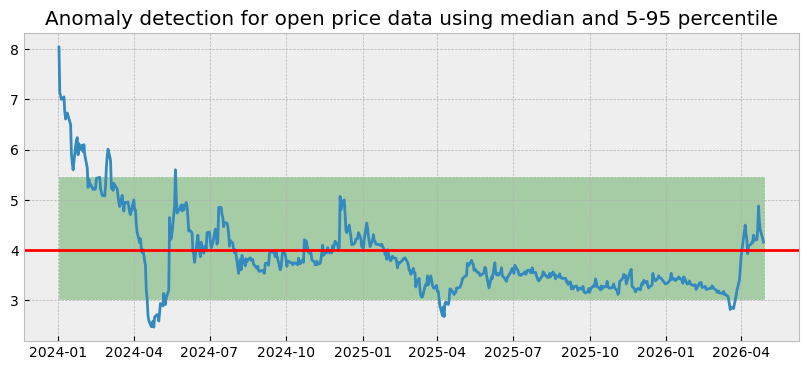

In [186]:


lower=np.percentile(df.open, 5)
upper = np.percentile(df.open, 95) 
plt.figure(figsize=(10,4)) 
plt.plot(df.date, df.open) 
plt.fill_between([min(df.date), max(df.date)], lower, upper, color='g', alpha=0.3, linestyle='--')


plt.axhline(y=4, color='r')
plt.title("Anomaly detection for open price data using median and 5-95 percentile")
plt.show()

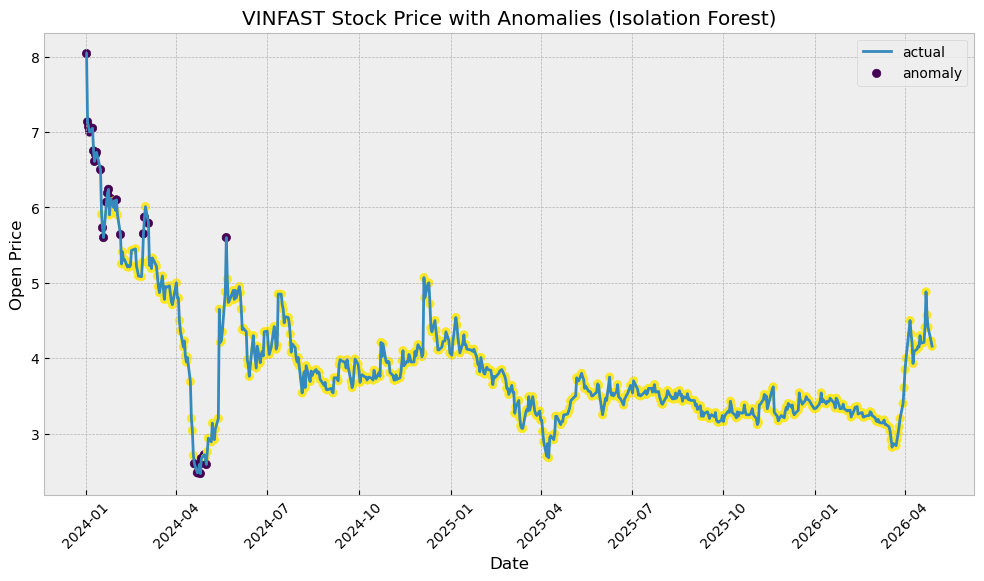

In [187]:
from sklearn.ensemble import IsolationForest

# Prepare the data for Isolation Forest
X = df['open'].values.reshape(-1, 1)

# Train the Isolation Forest model
model = IsolationForest(contamination=0.05)
model.fit(X)

# Predict the anomalies
anomalies = model.predict(X)

# Plot the anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.date, df['open'])
plt.scatter(df.date, df['open'], c=anomalies, label='Anomaly')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('VINFAST Stock Price with Anomalies (Isolation Forest)')
plt.xticks(rotation=45)
plt.legend(['actual', 'anomaly'])
plt.grid(True)

plt.show()

In [188]:
anomalies

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1,  1,
       -1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

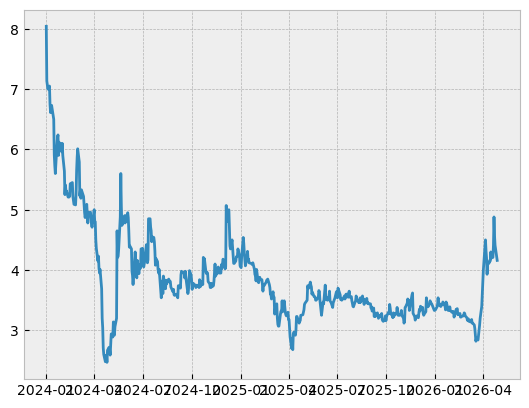

In [189]:
plt.plot(df.date, df.open)

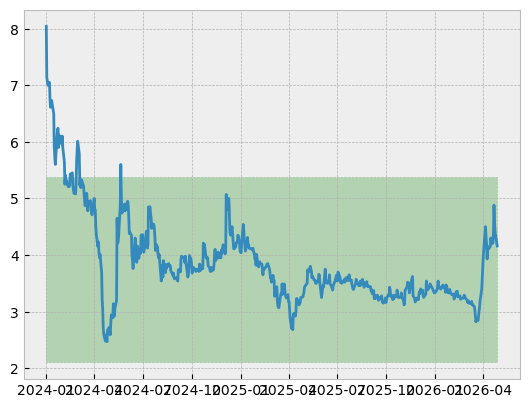

In [190]:
iqr = stats.iqr(df['open']) 

upper = (1.5*iqr) + np.percentile(df['open'], 75)
lower = np.percentile(df['open'], 25) - (1.5*iqr) 

plt.plot(df.date, df.open) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', linestyle='--', alpha=0.25)

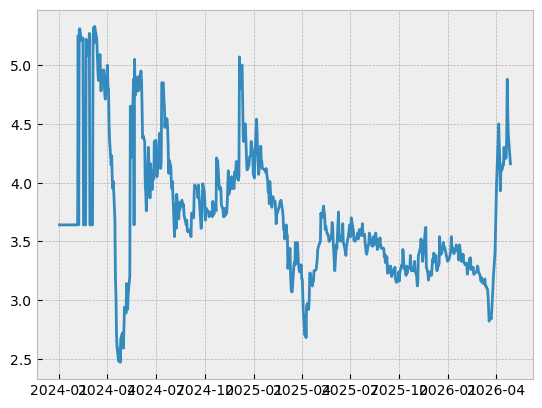

In [191]:
iqr = stats.iqr(df['open']) 

upper = (1.5*iqr) + np.percentile(df['open'], 75)
lower = np.percentile(df['open'], 25) - (1.5*iqr) 

plt.plot(df.date, df.open_imputed) 



In [192]:
df.open_imputed

0      3.64
1      3.64
2      3.64
3      3.64
4      3.64
       ... 
577    4.88
578    4.57
579    4.41
580    4.23
581    4.16
Name: open_imputed, Length: 582, dtype: float64

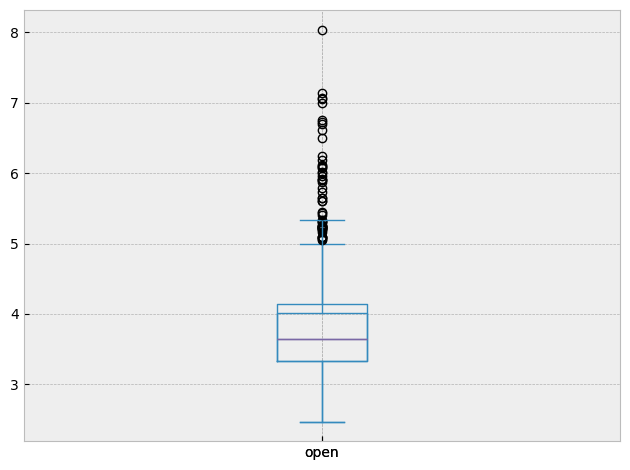

In [193]:
df['open_imputed'].plot(kind='box')
df['open'].plot(kind='box')
plt.tight_layout()

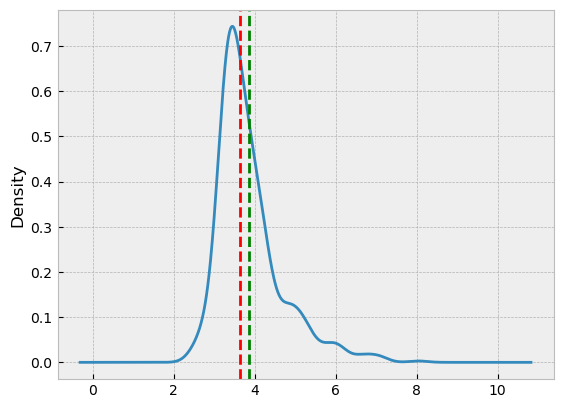

In [194]:

plt.ylabel("Open Price $")

df['open'].plot(kind='kde')
plt.axvline(x=df['open'].median(), color='r', linestyle='--')
plt.axvline(x=df['open'].mean(), color='g', linestyle='--')
plt.show()

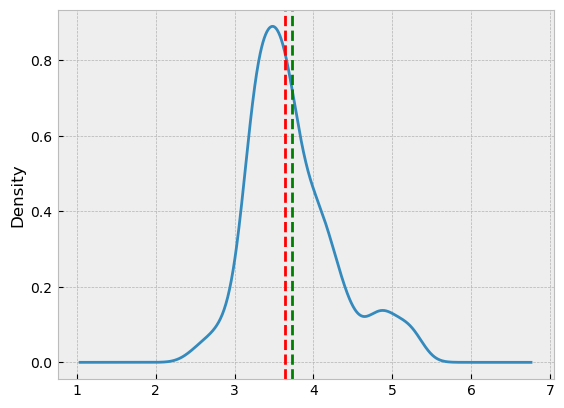

In [195]:

plt.ylabel("Open Price $ imputed")

df['open_imputed'].plot(kind='kde')
plt.axvline(x=df['open_imputed'].median(), color='r', linestyle='--')
plt.axvline(x=df['open_imputed'].mean(), color='g', linestyle='--')
plt.show()

# Building the model

In [196]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor


In [197]:
print (np.shape(X_train)) 
print (np.shape(Y_train)) 
print ("---")
print (np.shape(X_test)) 
print (np.shape(Y_test))

(465, 6)
(465, 1)
---
(115, 6)
(115, 1)


In [198]:
X_train.head()

,day,month,year,lagged_adjusted_close,lagged_high,lagged_low
1,3,1,2024,3.75,3.83,3.6875
2,4,1,2024,3.75,3.83,3.6875
3,5,1,2024,3.75,3.83,3.6875
4,8,1,2024,3.75,3.83,3.6875
5,9,1,2024,3.75,3.83,3.6875


In [199]:
import joblib

In [237]:
model = XGBRegressor(eta=0.1, min_child_weight=0)

model.fit(X_train, Y_train)


pred = model.predict(X_test)

In [238]:
# metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [239]:
print (root_mean_squared_error(y_pred=pred, y_true=Y_test))
print (mean_absolute_error(y_pred=pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=pred))


0.06436905045456208
0.04053399648251741
0.9730086021408842


In [240]:
df.tail(test_size).date

466   2025-11-10
467   2025-11-11
468   2025-11-12
469   2025-11-13
470   2025-11-14
         ...    
577   2026-04-22
578   2026-04-23
579   2026-04-24
580   2026-04-27
581   2026-04-28
Name: date, Length: 116, dtype: datetime64[ns]

In [241]:
np.shape(pred)

(115,)

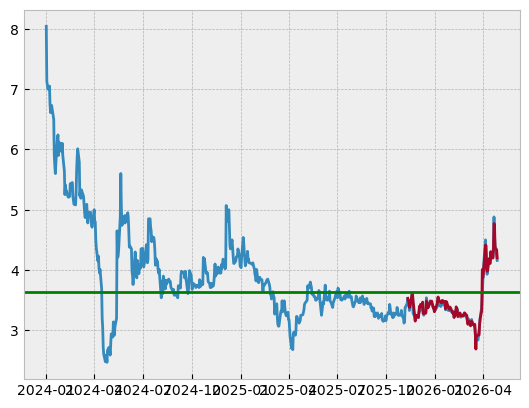

In [242]:
# plotting


plt.plot(df.date, df.open)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.axhline(y=df['open'].median(), color='g')

Text(0.5, 1.0, 'Zoomed in VINFAST opening prices prediction. R2 = 0.973')

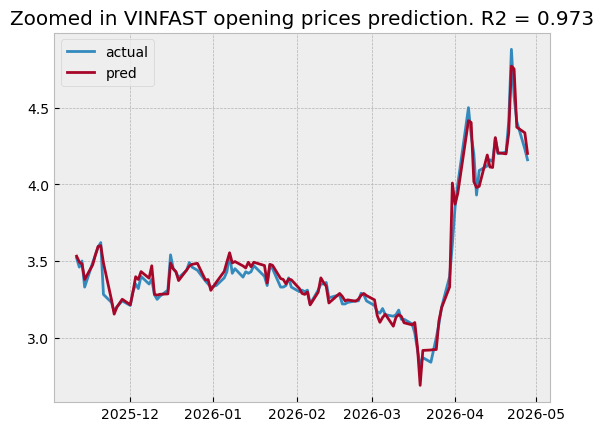

In [243]:
plt.plot(df.tail(test_size).date.iloc[1:], Y_test)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.legend(['actual', 'pred'])

plt.title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")

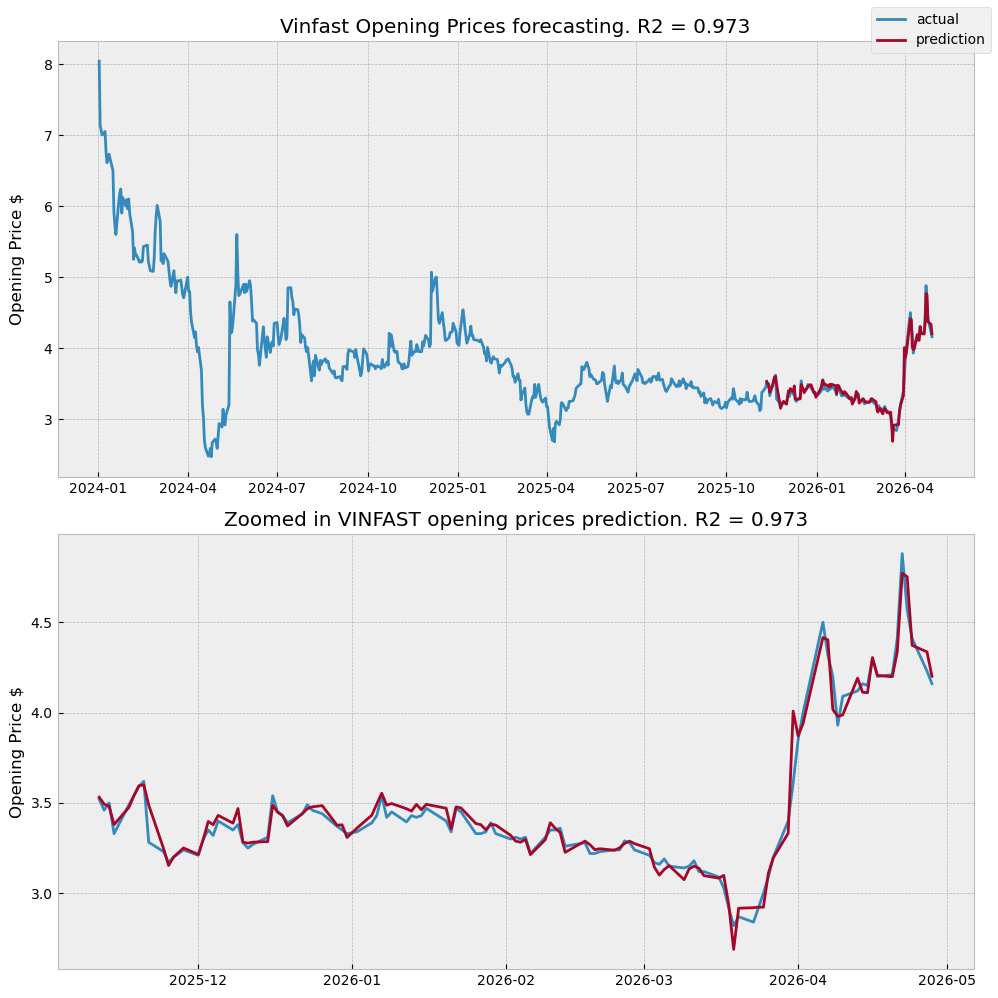

In [244]:
# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.open)
axes[0].plot(df.tail(test_size).date.iloc[1:], pred)



axes[0].set_title(f"Vinfast Opening Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[0].set_ylabel("Opening Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], pred)



axes[1].set_title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[1].set_ylabel("Opening Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Y test')

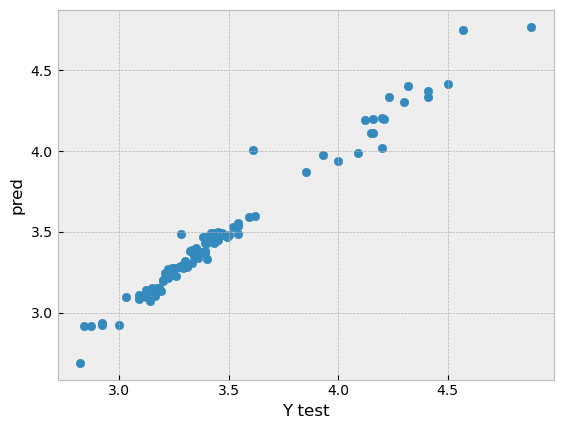

In [245]:
plt.scatter(Y_test, pred) 
plt.ylabel("pred") 
plt.xlabel("Y test")

In [246]:
X_train.shape

(465, 6)

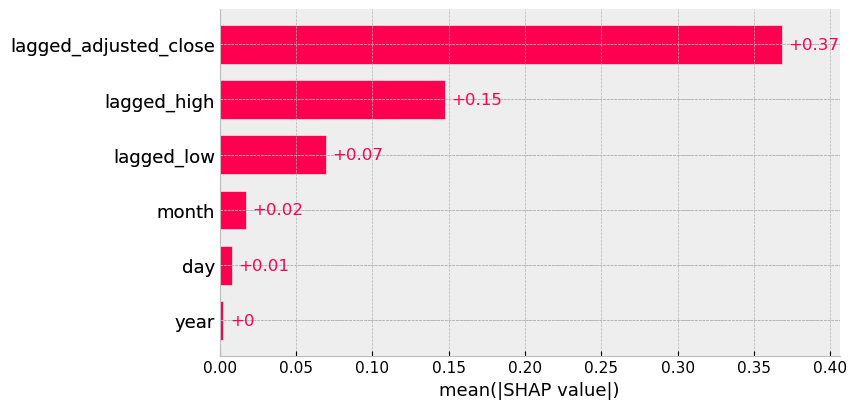

In [247]:
import shap 


explainer = shap.TreeExplainer(model) 
shap_values = explainer(X_test) 


shap.plots.bar(shap_values)

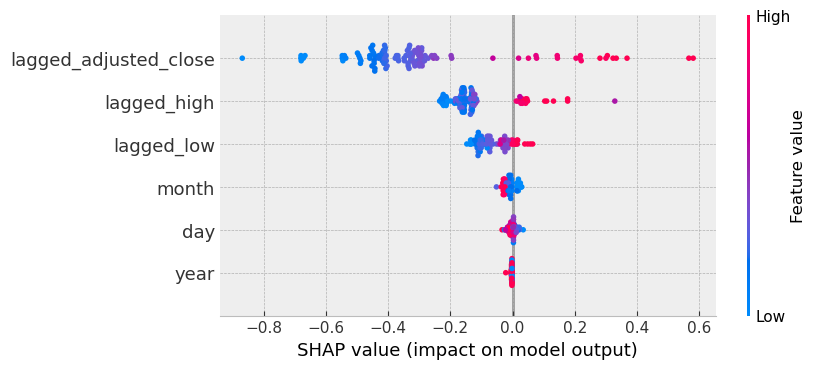

In [248]:
shap.plots.beeswarm(shap_values)

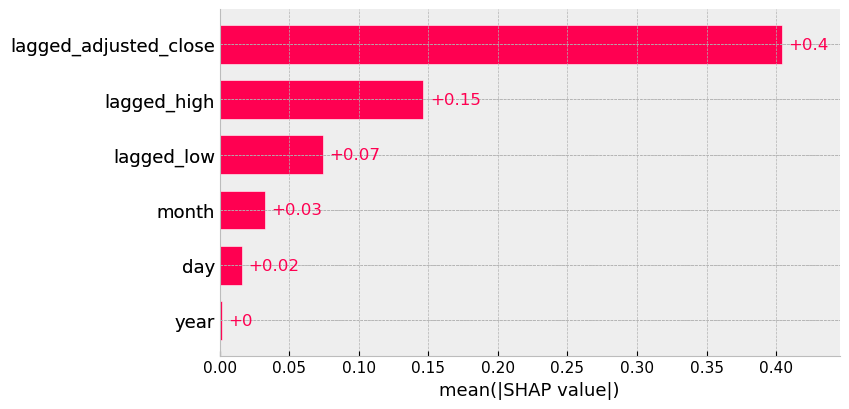

In [249]:



train_shap_values = explainer(X_train) 


shap.plots.bar(train_shap_values)

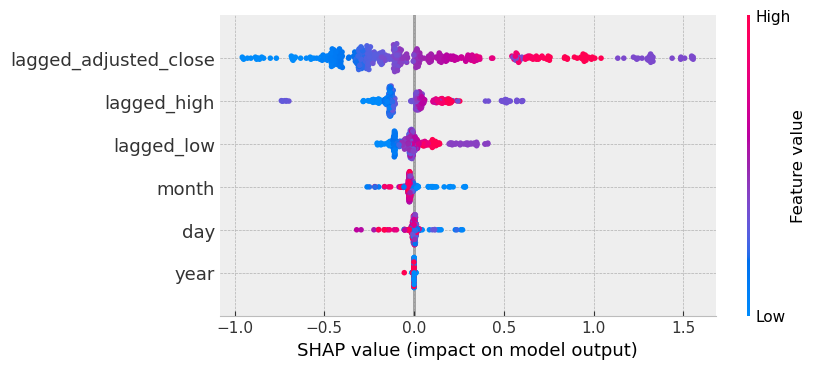

In [250]:



train_shap_values = explainer(X_train) 


shap.plots.beeswarm(train_shap_values)

In [251]:
X_test.head()

,day,month,year,lagged_adjusted_close,lagged_high,lagged_low
467,11,11,2025,3.530,3.630,3.42
468,12,11,2025,3.485,3.570,3.46
469,13,11,2025,3.470,3.490,3.40
470,14,11,2025,3.360,3.510,3.33
471,17,11,2025,3.460,3.515,3.33


In [252]:
import joblib

In [253]:
import joblib 

joblib.dump(model, "../models/time_series/vinfast_open_forecaster.pkl")

['../models/time_series/vinfast_open_forecaster.pkl']

In [254]:
import sys 
sys.path.append("../scripts/")
from clean_vinfast_stock import column_cleaner

In [255]:
X_train.columns

Index(['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_high',
       'lagged_low'],
      dtype='object')

In [256]:
print ("Predicting opening price for 5/05/2026")
first_may = pd.DataFrame({
    'day': [5],
    'month': [5],
    'year': [2026],
    'lagged_adjusted_close': [4.21],
    'lagged_high': [4.27],
    'lagged_low': [4.16],
    


})

mae = mean_absolute_error(y_true=Y_test, y_pred=pred)

first_may_cleaned = column_cleaner(first_may) 
first_may_cleaned = first_may_cleaned.clean_columns() 

prediction = model.predict(first_may_cleaned) 
print (f"Prediction: {prediction}")
print (f"upper bound: {prediction + mae}")
print (f"lower bound: {prediction - mae}")



Predicting opening price for 5/05/2026
Imputing 'lagged_adjusted_close'...
  Done — column 'lagged_adjusted_close' imputed.
Imputing 'lagged_high'...
  Done — column 'lagged_high' imputed.
Imputing 'lagged_low'...
  Done — column 'lagged_low' imputed.
   day  month  year  lagged_adjusted_close  lagged_high  lagged_low
0    5      5  2026                   4.21         4.27        4.16
Prediction: [4.191457]
upper bound: [4.231991]
lower bound: [4.150923]


In [234]:
first_may_cleaned

,day,month,year,lagged_adjusted_close,lagged_high,lagged_low
0,5,5,2026,4.21,4.27,4.16


In [285]:
mae

0.0

# Training a "High" forecaster

In [279]:
import sys 
sys.path.append("../scripts/") 
from clean_time_series import clean_iqr

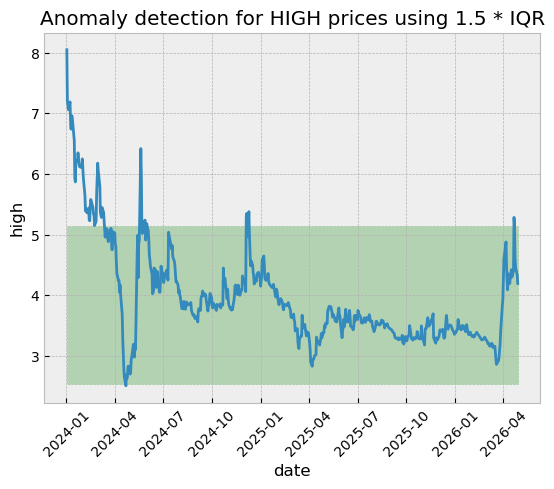

In [257]:
sns.lineplot(x=df.date, y=df.high)
plt.xticks(rotation=45)


# calculating upper and lower using iqr 
iqr = stats.iqr(df.high) 
upper = iqr + np.percentile(df.high, 75) 
lower = np.percentile(df.high, 25) - iqr 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=.25, linestyle='--')

plt.title("Anomaly detection for HIGH prices using 1.5 * IQR")


plt.show()

In [258]:
# anomaly detection using isolation forest

from sklearn.ensemble import IsolationForest

# Prepare the data
high_anomalies = df[['high']].copy()

# Fit Isolation Forest
iso_forest = IsolationForest(
    contamination='auto',  # Expected proportion of anomalies (5%)
    random_state=42,
    n_estimators=100
)

df['anomaly'] = iso_forest.fit_predict(high_anomalies)
df['anomaly_score'] = iso_forest.decision_function(high_anomalies)

# -1 = anomaly, 1 = normal
df['is_anomaly'] = df['anomaly'] == -1

# View anomalies
anomalies = df[df['is_anomaly']][['date', 'high', 'anomaly_score']]
print(f"Found {len(anomalies)} anomalies out of {len(df)} records")
print(anomalies)

Found 152 anomalies out of 582 records
          date   high  anomaly_score
0   2024-01-02  8.050      -0.288611
1   2024-01-03  7.210      -0.226131
2   2024-01-04  7.130      -0.215402
3   2024-01-05  7.060      -0.210578
4   2024-01-08  7.190      -0.223678
..         ...    ...            ...
573 2026-04-16  4.420      -0.000534
576 2026-04-21  5.285      -0.026740
577 2026-04-22  5.120      -0.019841
578 2026-04-23  4.605      -0.043257
579 2026-04-24  4.450      -0.000533

[152 rows x 3 columns]


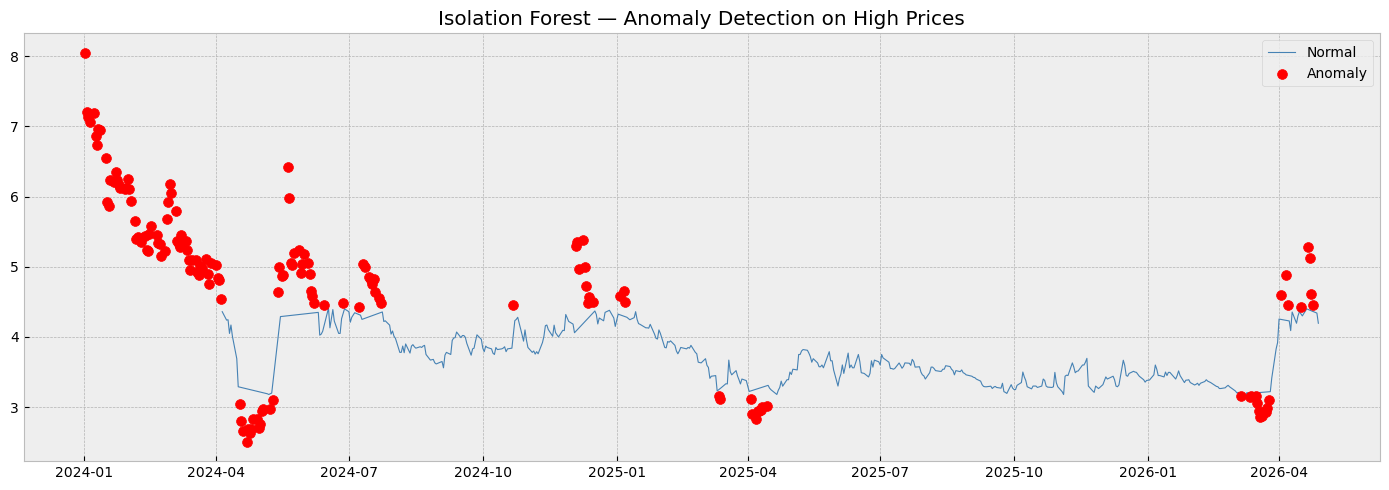

In [259]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

# Normal points
normal = df[~df['is_anomaly']]
ax.plot(normal['date'], normal['high'], color='steelblue', label='Normal', linewidth=0.8)

# Anomalies
ax.scatter(anomalies['date'], anomalies['high'],
           color='red', zorder=5, label='Anomaly', s=50)

ax.set_title('Isolation Forest — Anomaly Detection on High Prices')
ax.legend()
plt.tight_layout()
plt.show()

In [260]:
df.head()

,date,open,high,low,close,adjusted_close,volume,day,month,year,open_imputed,anomaly,anomaly_score,is_anomaly
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200,2,1,2024,3.64,-1,-0.288611,True
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600,3,1,2024,3.64,-1,-0.226131,True
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600,4,1,2024,3.64,-1,-0.215402,True
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900,5,1,2024,3.64,-1,-0.210578,True
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900,8,1,2024,3.64,-1,-0.223678,True


In [263]:
# ---------- Preparing hte data to predict the high


## -------------------------------------- imputing


print ("Creating day, month, year...")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date'],ascending=True)



df = df.sort_values(['date'],ascending=True) 
print ("Splitting into X_train, X_test, Y_train, Y_test...")
X = df[['open_imputed','low', 'adjusted_close', 'day', 'month', 'year']]
train_size=round(df.shape[0]*0.8)
test_size=round(df.shape[0]*0.2)
# replacing the anomalies
X_train = X.head(train_size)
 
X_test = X.tail(test_size)




def impute_median(column): 
    print (f"Computing for column: {column}")
    median = X_train[column].median() 
    print (f"median: {median}")
    std = X_train[column].std() 
    print (f"std: {std}")
    mean = X_train[column].mean() 
    print (f"mean: {mean}")
    # calculating the upper limit

    iqr = stats.iqr(df[column])


    upper = (1.5 * iqr) + np.percentile(X_train[column], 75)
    lower=np.percentile(X_train[column], 25) - (1.5 * iqr)
    print (f"upper: {upper}")
    print (f"lower: {lower}")
    # checking if the value is above or below 
    print ("Imputing...")

    values = [median if value > upper or value < lower else value for value in X_train[column]]
    print ("Done") 
    print ("----------------------")
    return values, median, upper, lower

print ("Imputing...")

# imputing mean for df['open']



for column in X_train: 
    # this will impute X_train and X_test simultaneously
    print (f"column: {column}")

    X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
    # saving the median values

    
    X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]

    print ("Done...")
    print ("------------------")



# ----------- IMPUTING FOR HIGH

# imputing mean for df['open']
iqr = stats.iqr(df['high']) 
upper = (1.5 * iqr) + np.percentile(df['high'], 75)
lower=np.percentile(df['high'], 25) - (1.5 * iqr)
median = df['high'].median()
df['high_imputed'] = [median if value > upper or value < lower else value for value in df['high']]






# -------------------------- CREATING THE LAGGING
y = df.high.values.reshape(-1,1)


# lagged adjusted close



lagged_adjusted_close = X_train['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_train['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted open
lagged_open = X_train['open_imputed'].values
lagged_open = np.insert(lagged_open, 0, 0) 
lagged_open = lagged_open[:-1]
X_train['lagged_open'] = lagged_open 

# lagged low 
lagged_low = X_train['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_train['lagged_low'] = lagged_low 

X_train.head()
# ----------------------------



# lagged adjusted close


lagged_adjusted_close = X_test['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_test['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted open
lagged_open = X_test['open_imputed'].values
lagged_open = np.insert(lagged_open, 0, 0) 
lagged_open = lagged_open[:-1]
X_test['lagged_open'] = lagged_open 

# lagged low 
lagged_low = X_test['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_test['lagged_low'] = lagged_low 












Y_train = y[0:train_size]
Y_train = Y_train[1:]
Y_test = y[train_size:df.shape[0]]
Y_test = Y_test[1:]

X_train = X_train.drop(['day_imputed', 'month_imputed', 'year_imputed', 'open_imputed_imputed', 'low', 'adjusted_close', 'open_imputed', 'low_imputed', 'adjusted_close_imputed'],axis=1).iloc[1:]
X_test = X_test.drop(['day_imputed', 'month_imputed', 'year_imputed', 'open_imputed_imputed', 'low', 'adjusted_close', 'open_imputed', 'low_imputed', 'adjusted_close_imputed'],axis=1).iloc[1:]


Creating day, month, year...
Splitting into X_train, X_test, Y_train, Y_test...
Imputing...
column: open_imputed
Computing for column: open_imputed
median: 3.66
std: 0.5745859960813491
mean: 3.7936630901287547
upper: 5.0874999999999995
lower: 2.4300000000000006
Imputing...
Done
----------------------
Done...
------------------
column: low
Computing for column: low
median: 3.6875
std: 0.7992202161378477
mean: 3.8586030042918456
upper: 5.203500000000001
lower: 2.241249999999999
Imputing...
Done
----------------------
Done...
------------------
column: adjusted_close
Computing for column: adjusted_close
median: 3.75
std: 0.8330754018429259
mean: 3.959388412017167
upper: 5.42375
lower: 2.2337500000000006
Imputing...
Done
----------------------
Done...
------------------
column: day
Computing for column: day
median: 15.5
std: 8.81051209909186
mean: 15.65236051502146
upper: 45.5
lower: -14.5
Imputing...
Done
----------------------
Done...
------------------
column: month
Computing for column

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/2942431230.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/2942431230.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/29424

In [264]:
X_train.columns

Index(['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_open',
       'lagged_low'],
      dtype='object')

In [265]:
np.shape(Y_train)

(465, 1)

In [266]:
np.shape(X_train)

(465, 6)

In [267]:
np.shape(Y_test)

(115, 1)

In [268]:
np.shape(X_test)

(115, 6)

In [284]:
clf = XGBRegressor() 

clf.fit(X_train, Y_train) 

high_pred = clf.predict(X_test) 

print (r2_score(y_true=Y_test, y_pred=high_pred))

print (mean_absolute_error(y_true=Y_test, y_pred=high_pred))


print (root_mean_squared_error(y_true=Y_test, y_pred=high_pred))

clf_mae = mean_absolute_error(y_true=Y_test, y_pred=high_pred)

0.8388994142133644
0.11810059333469555
0.18445671393679347


In [271]:
# attempting skopt bayes search
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer


In [272]:
param_grid = {
    'eta': Real(0.001, 0.5, prior='log-uniform'),
    'tree_method': Categorical(['auto', 'hist', 'exact', 'approx']),
    'max_depth': Integer(6, 50, prior='log-uniform'),
    'num_parallel_tree': Integer(1, 5)
    
}


grid_search = BayesSearchCV(
    estimator=XGBRegressor(n_estimators=30, min_child_weight=0),
    search_spaces=param_grid,
    verbose=3,
    return_train_score=True,
    cv=5,
    scoring='r2',
    n_iter=100,
    n_jobs=-1
)

_ = grid_search.fit(X_train, Y_train) 



Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 4/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.097, test=-7.632) total time=   0.0s
[CV 3/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.098, test=-0.034) total time=   0.0s
[CV 2/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.098, test=-0.168) total time=   0.0s
[CV 5/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.097, test=-28.826) total time=   0.0s
[CV 1/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.094, test=-0.742) total time=   0.0s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 3/5] END eta=0.2247557242929123, max_depth=13, num_parallel_tree=4, tree_method=exact;, score=(train=1.000, test=-0.155) total time=   0.1s
[CV 4/5] END

/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.49999999999999994, 6, 5, 'auto'] before, using random point [0.04905579293774474, 6, 2, 'auto']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.897, test=-0.388) total time=   0.0s
[CV 3/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.922, test=0.528) total time=   0.0s
[CV 2/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.925, test=0.546) total time=   0.0s
[CV 4/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.917, test=0.176) total time=   0.0s
[CV 5/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.916, test=-3.584) total time=   0.0s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END eta=0.17527333035869191, max_depth=6, num_parallel_tree=5, tree_method=hist;, score=(train=0.993, test=-0.233) total time=   0.1s
[CV 2/5] END eta=0.17527333

In [273]:
grid_pred = grid_search.predict(X_test) 

print (r2_score(y_true=Y_test, y_pred=grid_pred))

print (mean_absolute_error(y_true=Y_test, y_pred=grid_pred))


print (root_mean_squared_error(y_true=Y_test, y_pred=grid_pred))

clf_mae = mean_absolute_error(y_true=Y_test, y_pred=grid_pred)


0.8065729766878179
0.10499565827742866
0.20211776253684627


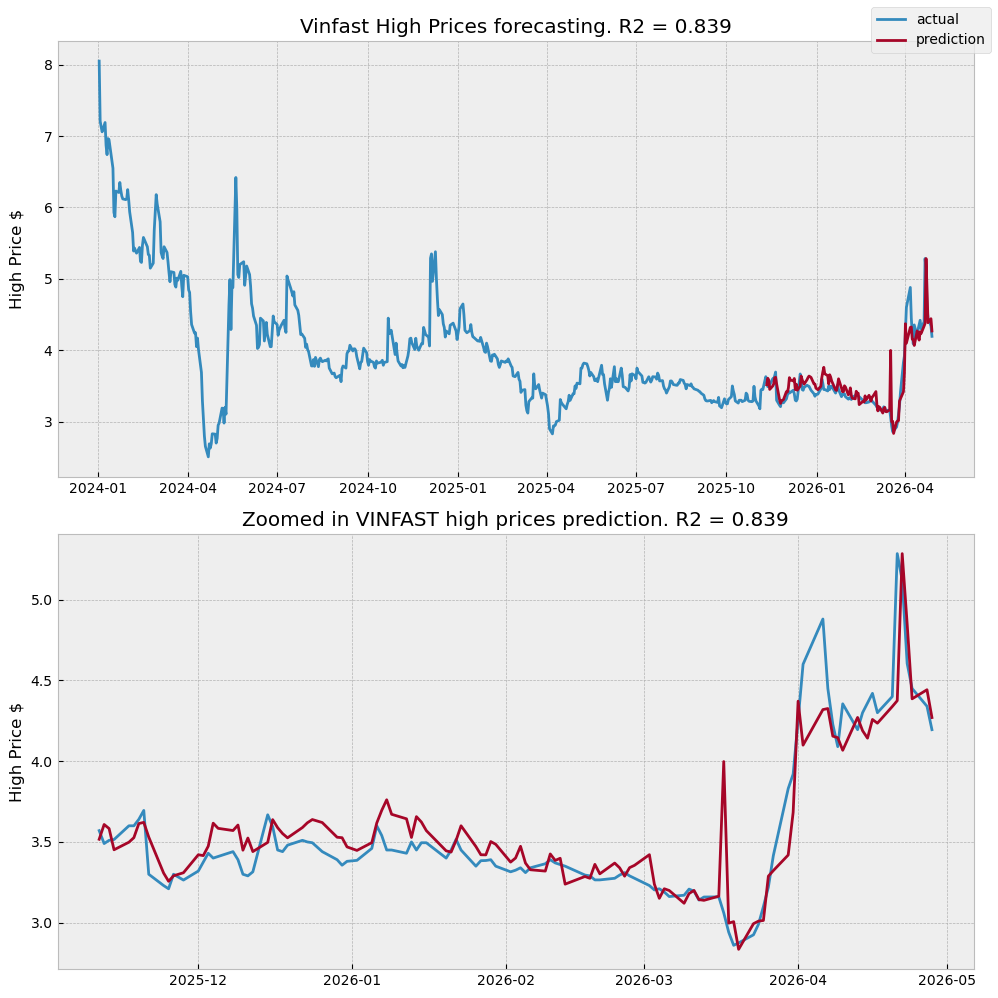

In [275]:
# plotting the lagged high 

# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.high)
axes[0].plot(df.tail(test_size).date.iloc[1:], high_pred)



axes[0].set_title(f"Vinfast High Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=high_pred), 3)}")
axes[0].set_ylabel("High Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], high_pred)



axes[1].set_title(f"Zoomed in VINFAST high prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=high_pred), 3)}")
axes[1].set_ylabel("High Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()



Text(0, 0.5, 'high pred')

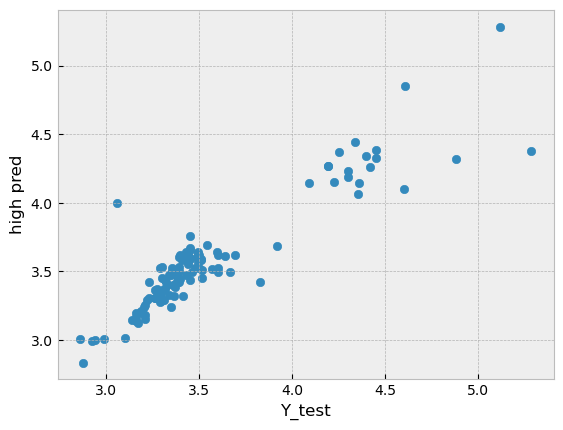

In [276]:
plt.scatter(Y_test, high_pred) 

plt.xlabel("Y_test") 
plt.ylabel("high pred")

In [277]:
X_train.columns

Index(['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_open',
       'lagged_low'],
      dtype='object')

In [278]:
X_train.columns

Index(['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_open',
       'lagged_low'],
      dtype='object')

In [285]:
# test prediction 

test_data1 = pd.DataFrame({
    'day': [5],
    'month':[5],
    'year':[2026],
    'lagged_adjusted_close': [4.21],
    'lagged_open': [4.22],

    'lagged_low':[4.16],


    



})
# cleaning 

print (test_data1)

test_data1_cleaned = column_cleaner(test_data1) 
test_data1_cleaned = test_data1_cleaned.clean_columns()



print ("Predicting the high for 5/05/2026")
test2_pred = clf.predict(test_data1_cleaned)
print (f"Prediction: {test2_pred}")
print (f"upper bound: {test2_pred + clf_mae}")
print (f"lower bound: {test2_pred - clf_mae}")


   day  month  year  lagged_adjusted_close  lagged_open  lagged_low
0    5      5  2026                   4.21         4.22        4.16
Imputing 'lagged_adjusted_close'...
  Done — column 'lagged_adjusted_close' imputed.
Imputing 'lagged_open'...
  Done — column 'lagged_open' imputed.
Imputing 'lagged_low'...
  Done — column 'lagged_low' imputed.
   day  month  year  lagged_adjusted_close  lagged_open  lagged_low
0    5      5  2026                   4.21         4.22        4.16
Predicting the high for 5/05/2026
Prediction: [4.5164814]
upper bound: [4.634582]
lower bound: [4.3983808]


In [ ]:
joblib.dump(clf, '../models/time_series/vinfast/vinfast_high_forecaster.pkl')

['../models/time_series/vinfast/vinfast_high_forecaster.pkl']

Exception ignored in: <function ResourceTracker.__del__ at 0x110fc9940>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/news_project/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/miniconda3/envs/news_project/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/miniconda3/envs/news_project/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107061940>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/news_project/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/miniconda3/envs/news_project/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/miniconda3/envs/news_project/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child 

In [ ]:
# predicting opening priee 

In [396]:
a = [("Thomas", 1, 2, 3), ("Natalie", 3, 4, 5)]
a


[('Thomas', 1, 2, 3), ('Natalie', 3, 4, 5)]

In [398]:
a[0][0]

'Thomas'

In [399]:
df

,index,date,open,high,low,close,adjusted_close,volume,day,month,year,open_imputed,high_imputed,anomaly,anomaly_score,is_anomaly
0,0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200,2,1,2024,3.64,3.740,-1,-0.288611,True
1,1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600,3,1,2024,3.64,3.740,-1,-0.226131,True
2,2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600,4,1,2024,3.64,3.740,-1,-0.215402,True
3,3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900,5,1,2024,3.64,3.740,-1,-0.210578,True
4,4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900,8,1,2024,3.64,3.740,-1,-0.223678,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,577,2026-04-22,4.880,5.120,4.580,4.69,4.69,1409000,22,4,2026,4.88,5.120,-1,-0.019841,True
578,578,2026-04-23,4.570,4.605,4.140,4.41,4.41,1333100,23,4,2026,4.57,4.605,-1,-0.043257,True
579,579,2026-04-24,4.410,4.450,4.335,4.36,4.36,457200,24,4,2026,4.41,4.450,-1,-0.000533,True
580,580,2026-04-27,4.230,4.340,4.157,4.21,4.21,650700,27,4,2026,4.23,4.340,1,0.026622,False


In [288]:
df.head()

,date,open,high,low,close,adjusted_close,volume,day,month,year,open_imputed,anomaly,anomaly_score,is_anomaly,high_imputed
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200,2,1,2024,3.64,-1,-0.288611,True,3.74
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600,3,1,2024,3.64,-1,-0.226131,True,3.74
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600,4,1,2024,3.64,-1,-0.215402,True,3.74
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900,5,1,2024,3.64,-1,-0.210578,True,3.74
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900,8,1,2024,3.64,-1,-0.223678,True,3.74


In [289]:
df = df[['date', 'open', 'adjusted_close', 'close', 'high', 'low', 'day', 'month', 'year']]

In [290]:
df

,date,open,adjusted_close,close,high,low,day,month,year
0,2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024
1,2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024
2,2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024
3,2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024
4,2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024
...,...,...,...,...,...,...,...,...,...
577,2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026
578,2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026
579,2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026
580,2026-04-27,4.230,4.21,4.21,4.340,4.157,27,4,2026


In [291]:
import sys 
sys.path.append("../scripts/")
from clean_time_series import clean_iqr

In [292]:
df.columns

Index(['date', 'open', 'adjusted_close', 'close', 'high', 'low', 'day',
       'month', 'year'],
      dtype='object')

In [293]:
b = clean_iqr(df)

In [294]:
b_transformed, b_stats = b.fit_transform()

Using the 1.5 * IQR method for anomaly detection...
Analysing column: open
Analysing column: adjusted_close
Analysing column: close
Analysing column: high
Analysing column: low
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...


ValueError: too many values to unpack (expected 2)

In [295]:
test = b.fit()
test

Calculating the upper, lower, median and iqr...
Analysing column: open
Analysing column: adjusted_close
Analysing column: close
Analysing column: high
Analysing column: low
Analysing column: open_iqr_imputed
Analysing column: adjusted_close_iqr_imputed
Analysing column: close_iqr_imputed
Analysing column: high_iqr_imputed
Analysing column: low_iqr_imputed


,column,iqr,median,upper,lower
0,open,0.81750,3.64000,5.373750,2.103750
1,adjusted_close,0.79750,3.62000,5.336250,2.146250
2,close,0.79750,3.62000,5.336250,2.146250
3,high,0.86750,3.74000,5.568750,2.098750
4,low,0.74900,3.55750,5.153500,2.157500
5,open_iqr_imputed,0.68000,3.64000,5.030000,2.310000
6,adjusted_close_iqr_imputed,0.65250,3.62000,4.973750,2.363750
7,close_iqr_imputed,0.65250,3.62000,4.973750,2.363750
8,high_iqr_imputed,0.72875,3.74000,5.221875,2.306875
9,low_iqr_imputed,0.59650,3.55625,4.772250,2.386250


In [296]:
plt.plot(df.date, df.open)

AttributeError: 'DataFrame' object has no attribute 'date'

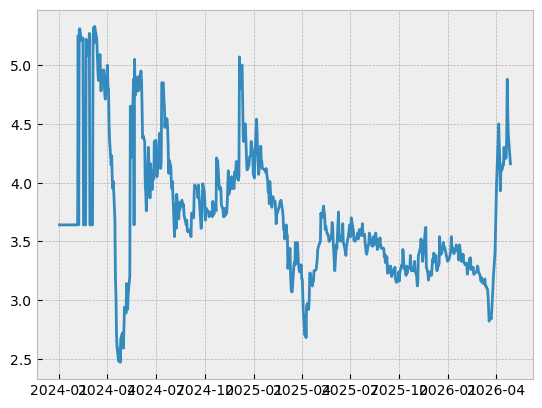

In [422]:
plt.plot(b_transformed.date, b_transformed.open_iqr_imputed)

In [298]:
df

,open,adjusted_close,close,high,low,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,close_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,,,,,,,,
2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024,3.64,3.62,3.62,3.740,3.5575
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026,4.88,4.69,4.69,5.120,4.5800
2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026,4.57,4.41,4.41,4.605,4.1400
2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026,4.41,4.36,4.36,4.450,4.3350


In [502]:
df.head()

,date,open,high,low,close,adjusted_close,volume
583,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
584,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
585,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
586,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
587,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


# Creating a model for lower

In [299]:
import sys 
sys.path.append("../scripts/")

In [300]:
from clean_time_series import clean_iqr

In [304]:
df.reset_index(inplace=True)
df

,date,open,adjusted_close,close,high,low,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,close_iqr_imputed,high_iqr_imputed,low_iqr_imputed
0,2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024,3.64,3.62,3.62,3.740,3.5575
1,2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024,3.64,3.62,3.62,3.740,3.5575
2,2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024,3.64,3.62,3.62,3.740,3.5575
3,2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024,3.64,3.62,3.62,3.740,3.5575
4,2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024,3.64,3.62,3.62,3.740,3.5575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026,4.88,4.69,4.69,5.120,4.5800
578,2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026,4.57,4.41,4.41,4.605,4.1400
579,2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026,4.41,4.36,4.36,4.450,4.3350
580,2026-04-27,4.230,4.21,4.21,4.340,4.157,27,4,2026,4.23,4.21,4.21,4.340,4.1570


In [311]:
# ---------- Preparing hte data to predict the low


## -------------------------------------- imputing


print ("Creating day, month, year...")


print ("Splitting into X_train, X_test, Y_train, Y_test...")
X = df[['date','open', 'adjusted_close', 'high', 'day', 'month', 'year']]
train_size=round(df.shape[0]*0.8)
test_size=round(df.shape[0]*0.2)
# replacing the anomalies
X_train = X.head(train_size)
print (f"X_train: {X_train}")
X_test = X.tail(test_size)
print (f"X_test: {X_test}")




# imputing median for df['lower']
X_train_lower_imputed = clean_iqr(X_train) 
X_train_stats = X_train_lower_imputed.fit() 
X_train_transformed = X_train_lower_imputed.fit_transform()
#----


X_test_lower_imputed = clean_iqr(X_test) 
X_test_lower_imputed = X_test_lower_imputed.transform(column_stats=X_train_stats, dataframe=X_test)


X_train = X_train_transformed
X_test = X_test_lower_imputed

# -------------------------- CREATING THE LAGGING



Creating day, month, year...
Splitting into X_train, X_test, Y_train, Y_test...
X_train:           date   open  adjusted_close   high  day  month  year
0   2024-01-02  8.040            7.05  8.050    2      1  2024
1   2024-01-03  7.135            7.08  7.210    3      1  2024
2   2024-01-04  7.070            7.07  7.130    4      1  2024
3   2024-01-05  7.000            7.02  7.060    5      1  2024
4   2024-01-08  7.050            6.79  7.190    8      1  2024
..         ...    ...             ...    ...  ...    ...   ...
461 2025-11-03  3.200            3.18  3.220    3     11  2025
462 2025-11-04  3.120            3.14  3.180    4     11  2025
463 2025-11-05  3.150            3.40  3.440    5     11  2025
464 2025-11-06  3.380            3.40  3.455    6     11  2025
465 2025-11-07  3.390            3.43  3.450    7     11  2025

[466 rows x 7 columns]
X_test:           date  open  adjusted_close   high  day  month  year
466 2025-11-10  3.45           3.530  3.630   10     11  2025

/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [313]:
X_train.drop(['open', 'high', 'adjusted_close'],axis=1,inplace=True) 
X_test.drop(['open', 'high',  'adjusted_close'],axis=1,inplace=True)

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/1533665901.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(['open', 'high', 'adjusted_close'],axis=1,inplace=True)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/1533665901.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(['open', 'high',  'adjusted_close'],axis=1,inplace=True)


In [314]:
X_test

,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,high_iqr_imputed
date,,,,,,
2025-11-10,10,11,2025,3.45,3.530,3.630
2025-11-11,11,11,2025,3.52,3.485,3.570
2025-11-12,12,11,2025,3.46,3.470,3.490
2025-11-13,13,11,2025,3.50,3.360,3.510
2025-11-14,14,11,2025,3.33,3.460,3.515
...,...,...,...,...,...,...
2026-04-22,22,4,2026,4.88,4.690,5.120
2026-04-23,23,4,2026,4.57,4.410,4.605
2026-04-24,24,4,2026,4.41,4.360,4.450


In [318]:
X_train.reset_index(inplace=True) 
X_test.reset_index(inplace=True)

In [323]:
X_train.head()

,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,high_iqr_imputed
date,,,,,,
2024-01-02,2,1,2024,3.75,3.75,3.83
2024-01-03,3,1,2024,3.75,3.75,3.83
2024-01-04,4,1,2024,3.75,3.75,3.83
2024-01-05,5,1,2024,3.75,3.75,3.83
2024-01-08,8,1,2024,3.75,3.75,3.83


In [324]:
X_test.index = pd.to_datetime(X_test['date'] )
X_test.drop(['date'],axis=1,inplace=True)

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/2536206123.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(['date'],axis=1,inplace=True)


In [325]:
y = df.low.values.reshape(-1,1)





# lagged adjusted close



lagged_adjusted_close = X_train['adjusted_close_iqr_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_train['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted open
lagged_open = X_train['open_iqr_imputed'].values
lagged_open = np.insert(lagged_open, 0, 0) 
lagged_open = lagged_open[:-1]
X_train['lagged_open'] = lagged_open 



# lagged adjusted open
lagged_high = X_train['high_iqr_imputed'].values
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_train['lagged_high'] = lagged_open 



# ----------------------------


# lagged adjusted close


lagged_adjusted_close = X_test['adjusted_close_iqr_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_test['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted open
lagged_open = X_test['open_iqr_imputed'].values
lagged_open = np.insert(lagged_open, 0, 0) 
lagged_open = lagged_open[:-1]
X_test['lagged_open'] = lagged_open 



lagged_high = X_test['high_iqr_imputed'].values
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_test['lagged_high'] = lagged_open 







Y_train = y[0:train_size]
Y_train = Y_train[1:]
Y_test = y[train_size:df.shape[0]]
Y_test = Y_test[1:]

X_train = X_train.iloc[1:]
X_test = X_test.iloc[1:]

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/4213723020.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['lagged_adjusted_close'] = lagged_adjusted_close
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/4213723020.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['lagged_open'] = lagged_open
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/4213723020.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [326]:
X_train.head()

,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,high_iqr_imputed,lagged_adjusted_close,lagged_open,lagged_high
date,,,,,,,,,
2024-01-03,3,1,2024,3.75,3.75,3.83,3.75,3.75,3.75
2024-01-04,4,1,2024,3.75,3.75,3.83,3.75,3.75,3.75
2024-01-05,5,1,2024,3.75,3.75,3.83,3.75,3.75,3.75
2024-01-08,8,1,2024,3.75,3.75,3.83,3.75,3.75,3.75
2024-01-09,9,1,2024,3.75,3.75,3.83,3.75,3.75,3.75


In [327]:
X_test.head()

,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,high_iqr_imputed,lagged_adjusted_close,lagged_open,lagged_high
date,,,,,,,,,
2025-11-11,11,11,2025,3.52,3.485,3.570,3.530,3.45,3.45
2025-11-12,12,11,2025,3.46,3.470,3.490,3.485,3.52,3.52
2025-11-13,13,11,2025,3.50,3.360,3.510,3.470,3.46,3.46
2025-11-14,14,11,2025,3.33,3.460,3.515,3.360,3.50,3.50
2025-11-17,17,11,2025,3.49,3.540,3.600,3.460,3.33,3.33


In [329]:
X_train.drop(['open_iqr_imputed', 'high_iqr_imputed', 'adjusted_close_iqr_imputed'], axis=1,inplace=True)
X_test.drop(['open_iqr_imputed', 'high_iqr_imputed', 'adjusted_close_iqr_imputed'], axis=1,inplace=True)

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/1134456751.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(['open_iqr_imputed', 'high_iqr_imputed', 'adjusted_close_iqr_imputed'], axis=1,inplace=True)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/1134456751.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(['open_iqr_imputed', 'high_iqr_imputed', 'adjusted_close_iqr_imputed'], axis=1,inplace=True)


In [330]:
X_train

,day,month,year,lagged_adjusted_close,lagged_open,lagged_high
date,,,,,,
2024-01-03,3,1,2024,3.75,3.75,3.75
2024-01-04,4,1,2024,3.75,3.75,3.75
2024-01-05,5,1,2024,3.75,3.75,3.75
2024-01-08,8,1,2024,3.75,3.75,3.75
2024-01-09,9,1,2024,3.75,3.75,3.75
...,...,...,...,...,...,...
2025-11-03,3,11,2025,3.20,3.25,3.25
2025-11-04,4,11,2025,3.18,3.20,3.20
2025-11-05,5,11,2025,3.14,3.12,3.12


In [331]:
np.shape(Y_train)

(465, 1)

In [332]:
from xgboost import XGBRegressor

In [333]:
low_clf = XGBRegressor(min_child_weight=0, eta=0.3, max_depth=6) 

low_clf.fit(X_train, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [334]:
low_pred = low_clf.predict(X_test)

In [335]:
# metrics 
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, median_absolute_error, mean_squared_error


In [336]:
print (f"r2: {r2_score(y_true=Y_test, y_pred=low_pred)}")
print (f"mean ae: {mean_absolute_error(y_true=Y_test, y_pred=low_pred)}")
print (F"median ae: {median_absolute_error(y_true=Y_test, y_pred=low_pred)}")
print (f"rmse: {root_mean_squared_error(y_true=Y_test, y_pred=low_pred)}")
print (f"mse: {mean_squared_error(y_true=Y_test, y_pred=low_pred)}")

r2: 0.9148938892218634
mean ae: 0.07363303002067234
median ae: 0.05099782943725595
rmse: 0.1032234722166629
mse: 0.010655085216464178


In [337]:
import joblib

In [338]:
joblib.dump(low_clf, '../models/time_series/vinfast/vinfast_low_forecaster.pkl')

['../models/time_series/vinfast/vinfast_low_forecaster.pkl']

<Axes: >

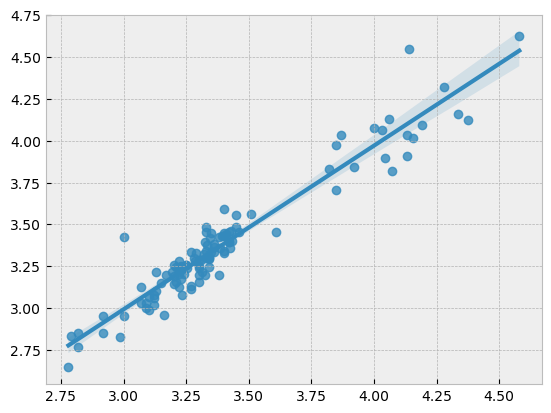

In [339]:
# plotting the results

sns.regplot(x=Y_test, y=low_pred)


# building a model for adjusted close

In [341]:
import joblib 
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real

In [342]:
df

,date,open,adjusted_close,close,high,low,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,close_iqr_imputed,high_iqr_imputed,low_iqr_imputed
0,2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024,3.64,3.62,3.62,3.740,3.5575
1,2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024,3.64,3.62,3.62,3.740,3.5575
2,2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024,3.64,3.62,3.62,3.740,3.5575
3,2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024,3.64,3.62,3.62,3.740,3.5575
4,2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024,3.64,3.62,3.62,3.740,3.5575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026,4.88,4.69,4.69,5.120,4.5800
578,2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026,4.57,4.41,4.41,4.605,4.1400
579,2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026,4.41,4.36,4.36,4.450,4.3350
580,2026-04-27,4.230,4.21,4.21,4.340,4.157,27,4,2026,4.23,4.21,4.21,4.340,4.1570


In [343]:
import sys 
sys.path.append("../scripts/")
from clean_time_series import clean_iqr

In [344]:
df.head()

,date,open,adjusted_close,close,high,low,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,close_iqr_imputed,high_iqr_imputed,low_iqr_imputed
0,2024-01-02,8.040,7.05,7.05,8.05,7.000,2,1,2024,3.64,3.62,3.62,3.74,3.5575
1,2024-01-03,7.135,7.08,7.08,7.21,6.835,3,1,2024,3.64,3.62,3.62,3.74,3.5575
2,2024-01-04,7.070,7.07,7.07,7.13,6.900,4,1,2024,3.64,3.62,3.62,3.74,3.5575
3,2024-01-05,7.000,7.02,7.02,7.06,6.900,5,1,2024,3.64,3.62,3.62,3.74,3.5575
4,2024-01-08,7.050,6.79,6.79,7.19,6.750,8,1,2024,3.64,3.62,3.62,3.74,3.5575


In [345]:
X = df[['date', 'open', 'high', 'low']]
y = df.adjusted_close.values.reshape(-1,1) 
TRAIN_SIZE=round(df.shape[0] * 0.8)
TEST_SIZE = round(df.shape[0] * 0.2) 


X_train = X.head(TRAIN_SIZE)
X_test=X.tail(TEST_SIZE)



In [346]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 466 to 581
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    116 non-null    datetime64[ns]
 1   open    116 non-null    float64       
 2   high    116 non-null    float64       
 3   low     116 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 3.8 KB


In [347]:
Y_train = y[0:TRAIN_SIZE]
Y_test = y[TRAIN_SIZE:len(y)]

Y_train_lag = Y_train[1:]
Y_test_lag = Y_test[1:]

In [348]:
np.shape(Y_test)

(116, 1)

In [349]:
X_train

,date,open,high,low
0,2024-01-02,8.040,8.050,7.000
1,2024-01-03,7.135,7.210,6.835
2,2024-01-04,7.070,7.130,6.900
3,2024-01-05,7.000,7.060,6.900
4,2024-01-08,7.050,7.190,6.750
...,...,...,...,...
461,2025-11-03,3.200,3.220,3.130
462,2025-11-04,3.120,3.180,3.100
463,2025-11-05,3.150,3.440,3.140
464,2025-11-06,3.380,3.455,3.295


In [350]:
X_test

,date,open,high,low
466,2025-11-10,3.45,3.630,3.420
467,2025-11-11,3.52,3.570,3.460
468,2025-11-12,3.46,3.490,3.400
469,2025-11-13,3.50,3.510,3.330
470,2025-11-14,3.33,3.515,3.330
...,...,...,...,...
577,2026-04-22,4.88,5.120,4.580
578,2026-04-23,4.57,4.605,4.140
579,2026-04-24,4.41,4.450,4.335
580,2026-04-27,4.23,4.340,4.157


In [351]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    582 non-null    datetime64[ns]
 1   open    582 non-null    float64       
 2   high    582 non-null    float64       
 3   low     582 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 18.3 KB


In [352]:
X_test

,date,open,high,low
466,2025-11-10,3.45,3.630,3.420
467,2025-11-11,3.52,3.570,3.460
468,2025-11-12,3.46,3.490,3.400
469,2025-11-13,3.50,3.510,3.330
470,2025-11-14,3.33,3.515,3.330
...,...,...,...,...
577,2026-04-22,4.88,5.120,4.580
578,2026-04-23,4.57,4.605,4.140
579,2026-04-24,4.41,4.450,4.335
580,2026-04-27,4.23,4.340,4.157


In [353]:
clean_iqr_X_train = clean_iqr(X_train)

column_stats = clean_iqr_X_train.fit() 
X_train_transformed = clean_iqr_X_train.fit_transform()
print ("-----------------------------------")
X_test_transformed = clean_iqr_X_train.transform(column_stats, dataframe=X_test)


Calculating the upper, lower, median and iqr...
Analysing column: open
Analysing column: high
Analysing column: low
Using the 1.5 * IQR method for anomaly detection...
Analysing column: open
Analysing column: high
Analysing column: low
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...
-----------------------------------
Transforming... Dataframe
median: [3.75]
upper: [5.375]
lower: [2.295]
Transforming... Dataframe
median: [3.83]
upper: [5.6625]
lower: [2.1865]
Transforming... Dataframe
median: [3.6875]
upper: [5.152875]
lower: [2.291875]


/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [354]:
column_stats

,column,iqr,median,upper,lower
0,open,0.77000,3.7500,5.375000,2.295000
1,high,0.86900,3.8300,5.662500,2.186500
2,low,0.71525,3.6875,5.152875,2.291875


In [355]:
X_test_transformed

,open,high,low,day,month,year,open_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,,,,
2025-11-10,3.45,3.630,3.420,10,11,2025,3.45,3.630,3.420
2025-11-11,3.52,3.570,3.460,11,11,2025,3.52,3.570,3.460
2025-11-12,3.46,3.490,3.400,12,11,2025,3.46,3.490,3.400
2025-11-13,3.50,3.510,3.330,13,11,2025,3.50,3.510,3.330
2025-11-14,3.33,3.515,3.330,14,11,2025,3.33,3.515,3.330
...,...,...,...,...,...,...,...,...,...
2026-04-22,4.88,5.120,4.580,22,4,2026,4.88,5.120,4.580
2026-04-23,4.57,4.605,4.140,23,4,2026,4.57,4.605,4.140
2026-04-24,4.41,4.450,4.335,24,4,2026,4.41,4.450,4.335


In [356]:
X_train_transformed

,open,high,low,day,month,year,open_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,,,,
2024-01-02,8.040,8.050,7.000,2,1,2024,3.75,3.830,3.6875
2024-01-03,7.135,7.210,6.835,3,1,2024,3.75,3.830,3.6875
2024-01-04,7.070,7.130,6.900,4,1,2024,3.75,3.830,3.6875
2024-01-05,7.000,7.060,6.900,5,1,2024,3.75,3.830,3.6875
2024-01-08,7.050,7.190,6.750,8,1,2024,3.75,3.830,3.6875
...,...,...,...,...,...,...,...,...,...
2025-11-03,3.200,3.220,3.130,3,11,2025,3.20,3.220,3.1300
2025-11-04,3.120,3.180,3.100,4,11,2025,3.12,3.180,3.1000
2025-11-05,3.150,3.440,3.140,5,11,2025,3.15,3.440,3.1400


In [357]:
X_train_transformed.drop(['open', 'high', 'low'],axis=1,inplace=True) 
X_test_transformed.drop(['open', 'high', 'low'],axis=1,inplace=True)

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/2023342621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_transformed.drop(['open', 'high', 'low'],axis=1,inplace=True)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/2023342621.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_transformed.drop(['open', 'high', 'low'],axis=1,inplace=True)


In [358]:
X_train_transformed

,day,month,year,open_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,
2024-01-02,2,1,2024,3.75,3.830,3.6875
2024-01-03,3,1,2024,3.75,3.830,3.6875
2024-01-04,4,1,2024,3.75,3.830,3.6875
2024-01-05,5,1,2024,3.75,3.830,3.6875
2024-01-08,8,1,2024,3.75,3.830,3.6875
...,...,...,...,...,...,...
2025-11-03,3,11,2025,3.20,3.220,3.1300
2025-11-04,4,11,2025,3.12,3.180,3.1000
2025-11-05,5,11,2025,3.15,3.440,3.1400


In [359]:
X_test_transformed

,day,month,year,open_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,
2025-11-10,10,11,2025,3.45,3.630,3.420
2025-11-11,11,11,2025,3.52,3.570,3.460
2025-11-12,12,11,2025,3.46,3.490,3.400
2025-11-13,13,11,2025,3.50,3.510,3.330
2025-11-14,14,11,2025,3.33,3.515,3.330
...,...,...,...,...,...,...
2026-04-22,22,4,2026,4.88,5.120,4.580
2026-04-23,23,4,2026,4.57,4.605,4.140
2026-04-24,24,4,2026,4.41,4.450,4.335


In [360]:
X_train_transformed_lag = clean_iqr_X_train.build_lagging(dataframe=X_train_transformed)
X_test_transformed_lag = clean_iqr_X_train.build_lagging(dataframe=X_test_transformed)

Created the lagged values...
Removing the first row
Created the lagged values...
Removing the first row


/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:244: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[f"lagged_{column}"] = lagged_values
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:244: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[f"lagged_{column}"] = lagged_values
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:244: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [361]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 116 entries, 2025-11-10 to 2026-04-28
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   day                      116 non-null    int32  
 1   month                    116 non-null    int32  
 2   year                     116 non-null    int32  
 3   open_iqr_imputed         116 non-null    float64
 4   high_iqr_imputed         116 non-null    float64
 5   low_iqr_imputed          116 non-null    float64
 6   lagged_open_iqr_imputed  116 non-null    float64
 7   lagged_high_iqr_imputed  116 non-null    float64
 8   lagged_low_iqr_imputed   116 non-null    float64
dtypes: float64(6), int32(3)
memory usage: 7.7 KB


In [362]:
X_train_transformed_lag.drop(['open_iqr_imputed', 'high_iqr_imputed', 'low_iqr_imputed'],axis=1,inplace=True)
X_test_transformed_lag.drop(['open_iqr_imputed', 'high_iqr_imputed', 'low_iqr_imputed'],axis=1,inplace=True)


/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/477915573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_transformed_lag.drop(['open_iqr_imputed', 'high_iqr_imputed', 'low_iqr_imputed'],axis=1,inplace=True)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_1716/477915573.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_transformed_lag.drop(['open_iqr_imputed', 'high_iqr_imputed', 'low_iqr_imputed'],axis=1,inplace=True)


In [363]:
X_test_transformed_lag.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 115 entries, 2025-11-11 to 2026-04-28
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   day                      115 non-null    int32  
 1   month                    115 non-null    int32  
 2   year                     115 non-null    int32  
 3   lagged_open_iqr_imputed  115 non-null    float64
 4   lagged_high_iqr_imputed  115 non-null    float64
 5   lagged_low_iqr_imputed   115 non-null    float64
dtypes: float64(3), int32(3)
memory usage: 4.9 KB


In [364]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, root_mean_squared_error, mean_squared_error

In [368]:
close_clf = XGBRegressor()
close_clf.fit(X_train_transformed_lag, Y_train_lag)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [369]:
close_pred = close_clf.predict(X_test_transformed_lag)

In [370]:
print (f"r2: {r2_score(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"mean ae: {mean_absolute_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (F"median ae: {median_absolute_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"rmse: {root_mean_squared_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"mse: {mean_squared_error(y_true=Y_test_lag, y_pred=close_pred)}")

r2: 0.8479684474543545
mean ae: 0.10302193434342097
median ae: 0.07076977729797385
rmse: 0.15436524135826823
mse: 0.023828627739596403


In [374]:
joblib.dump(close_clf, '../models/time_series/vinfast/vinfast_adjusted_close_forecaster.pkl')

['../models/time_series/vinfast/vinfast_adjusted_close_forecaster.pkl']

In [372]:
param_grid = {
    'max_depth': Integer(6, 30),
    'eta': Real(0.01, 0.4, prior='log-uniform'),
    'min_child_weight': Integer(0,1),
    'tree_method': Categorical(['exact', 'hist', 'auto'])
    
}


bayes = BayesSearchCV(
    estimator=XGBRegressor(),
    search_spaces=param_grid,
    verbose=3,
    return_train_score=True,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    n_iter=100
)

_ = bayes.fit(X_train_transformed_lag, Y_train_lag)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 5/5] END eta=0.02329442756702808, max_depth=6, min_child_weight=1, tree_method=auto;, score=(train=0.967, test=-1.003) total time=   0.0s
[CV 4/5] END eta=0.02329442756702808, max_depth=6, min_child_weight=1, tree_method=auto;, score=(train=0.972, test=-0.395) total time=   0.0s
[CV 3/5] END eta=0.02329442756702808, max_depth=6, min_child_weight=1, tree_method=auto;, score=(train=0.974, test=0.554) total time=   0.0s
[CV 2/5] END eta=0.02329442756702808, max_depth=6, min_child_weight=1, tree_method=auto;, score=(train=0.977, test=0.510) total time=   0.0s
[CV 1/5] END eta=0.02329442756702808, max_depth=6, min_child_weight=1, tree_method=auto;, score=(train=0.956, test=-0.368) total time=   0.0s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 3/5] END eta=0.21515763421372575, max_depth=12, min_child_weight=0, tree_method=exact;, score=(train=1.000, test=0.190) total time=   0.0s
[CV 5/5] END eta=0.215157634213

In [373]:
close_pred = close_clf.predict(X_test_transformed_lag)

print (f"r2: {r2_score(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"mean ae: {mean_absolute_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (F"median ae: {median_absolute_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"rmse: {root_mean_squared_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"mse: {mean_squared_error(y_true=Y_test_lag, y_pred=close_pred)}")

r2: 0.8479684474543545
mean ae: 0.10302193434342097
median ae: 0.07076977729797385
rmse: 0.15436524135826823
mse: 0.023828627739596403


In [52]:
bayes.best_params_

OrderedDict([('eta', 0.0525222928036933),
             ('max_depth', 30),
             ('min_child_weight', 1),
             ('tree_method', 'exact')])

In [53]:
bayes.best_score_

0.17016357328571935

In [54]:
X_train

,day,month,year,open_iqr_imputed,high_iqr_imputed,volume_iqr_imputed,low_iqr_imputed,lagged_open_iqr_imputed,lagged_high_iqr_imputed,lagged_volume_iqr_imputed,lagged_low_iqr_imputed
date,,,,,,,,,,,
2024-01-02,2,1,2024,3.75,3.830,734450.0,3.6875,0.00,0.000,0.0,0.0000
2024-01-03,3,1,2024,3.75,3.830,734450.0,3.6875,3.75,3.830,734450.0,3.6875
2024-01-04,4,1,2024,3.75,3.830,734450.0,3.6875,3.75,3.830,734450.0,3.6875
2024-01-05,5,1,2024,3.75,3.830,1939900.0,3.6875,3.75,3.830,734450.0,3.6875
2024-01-08,8,1,2024,3.75,3.830,734450.0,3.6875,3.75,3.830,1939900.0,3.6875
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-03,3,11,2025,3.20,3.220,680700.0,3.1300,3.25,3.290,575100.0,3.2000
2025-11-04,4,11,2025,3.12,3.180,641400.0,3.1000,3.20,3.220,680700.0,3.1300
2025-11-05,5,11,2025,3.15,3.440,1620000.0,3.1400,3.12,3.180,641400.0,3.1000


In [55]:
X_train.columns

Index(['day', 'month', 'year', 'open_iqr_imputed', 'high_iqr_imputed',
       'volume_iqr_imputed', 'low_iqr_imputed', 'lagged_open_iqr_imputed',
       'lagged_high_iqr_imputed', 'lagged_volume_iqr_imputed',
       'lagged_low_iqr_imputed'],
      dtype='object')